### 1

In [1]:
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd
import numpy as np


In [2]:
dataset_path = 'dataset/Base.csv'
data = pd.read_csv(dataset_path)

In [3]:
fraud = data[data['fraud_bool'] == 1]
legal = data[data['fraud_bool'] == 0]
legal_downsampled = resample(legal, replace=False, n_samples=len(fraud), random_state=42)
balanced_data = pd.concat([fraud, legal_downsampled])

In [4]:
le = LabelEncoder()
cat_cols = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
for col in cat_cols:
    balanced_data[col] = le.fit_transform(balanced_data[col])

In [5]:
X = balanced_data.drop('fraud_bool', axis=1)
y = balanced_data['fraud_bool']

Top 4 feature selezionate:
housing_status                  0.091987
current_address_months_count    0.072605
device_os                       0.070340
credit_risk_score               0.062858
dtype: float64


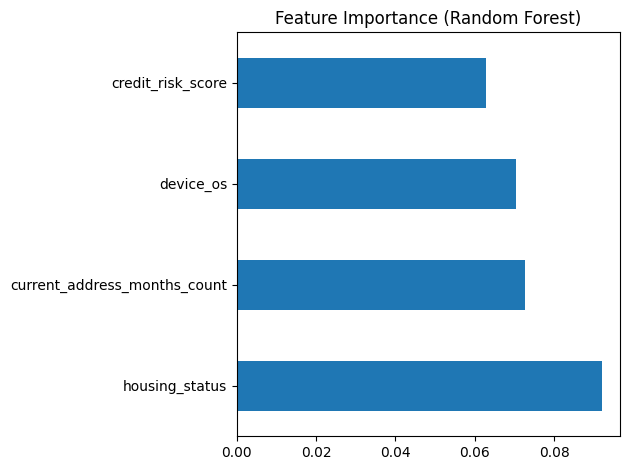

In [6]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).nlargest(4)
print('Top 4 feature selezionate:')
print(importances)

top_features = importances.index.tolist()
X_selected = X[top_features].values

importances.plot(kind='barh', title='Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()


In [7]:
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_final = scaler.fit_transform(X_selected)

print(f'Forma finale del dataset: {X_final.shape}')
print(f'Feature usate: {top_features}')

Forma finale del dataset: (22058, 4)
Feature usate: ['housing_status', 'current_address_months_count', 'device_os', 'credit_risk_score']


### 2

In [8]:
from qiskit.circuit.library import ZZFeatureMap

num_qubits = 4
feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=1, entanglement='linear')
print(feature_map.decompose().draw(output='text'))


     ┌───┐┌───────────┐                                             »
q_0: ┤ H ├┤ P(2*x[0]) ├──■──────────────────────────────────■───────»
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐     »
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├──■──»
     ├───┤├───────────┤└───┘└────────────────────────────┘└───┘┌─┴─┐»
q_2: ┤ H ├┤ P(2*x[2]) ├────────────────────────────────────────┤ X ├»
     ├───┤├───────────┤                                        └───┘»
q_3: ┤ H ├┤ P(2*x[3]) ├─────────────────────────────────────────────»
     └───┘└───────────┘                                             »
«                                                                           »
«q_0: ──────────────────────────────────────────────────────────────────────»
«                                                                           »
«q_1: ────────────────────────────────■─────────────────────────────────────»
«     ┌────────────────────────────┐┌─┴─┐                 

/var/folders/yk/25q_p_x52n166h2ndccz081h0000gn/T/ipykernel_4855/2794626542.py:4: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=1, entanglement='linear')


### 3

In [9]:
from sklearn.model_selection import train_test_split
 
# Dividiamo il dataset (es. 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"Campioni di training: {len(X_train)}")
print(f"Campioni di test: {len(X_test)}")

Campioni di training: 17646
Campioni di test: 4412


In [10]:
from qiskit.circuit.library import EfficientSU2

ansatz = EfficientSU2(num_qubits=num_qubits, reps=1, entanglement='linear')
print(ansatz.decompose().draw(output='text'))


     ┌──────────┐┌──────────┐     ┌──────────┐┌───────────┐             »
q_0: ┤ Ry(θ[0]) ├┤ Rz(θ[4]) ├──■──┤ Ry(θ[8]) ├┤ Rz(θ[12]) ├─────────────»
     ├──────────┤├──────────┤┌─┴─┐└──────────┘└┬──────────┤┌───────────┐»
q_1: ┤ Ry(θ[1]) ├┤ Rz(θ[5]) ├┤ X ├─────■───────┤ Ry(θ[9]) ├┤ Rz(θ[13]) ├»
     ├──────────┤├──────────┤└───┘   ┌─┴─┐     └──────────┘├───────────┤»
q_2: ┤ Ry(θ[2]) ├┤ Rz(θ[6]) ├────────┤ X ├──────────■──────┤ Ry(θ[10]) ├»
     ├──────────┤├──────────┤        └───┘        ┌─┴─┐    ├───────────┤»
q_3: ┤ Ry(θ[3]) ├┤ Rz(θ[7]) ├─────────────────────┤ X ├────┤ Ry(θ[11]) ├»
     └──────────┘└──────────┘                     └───┘    └───────────┘»
«                  
«q_0: ─────────────
«                  
«q_1: ─────────────
«     ┌───────────┐
«q_2: ┤ Rz(θ[14]) ├
«     ├───────────┤
«q_3: ┤ Rz(θ[15]) ├
«     └───────────┘


/var/folders/yk/25q_p_x52n166h2ndccz081h0000gn/T/ipykernel_4855/3273947560.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=num_qubits, reps=1, entanglement='linear')


In [11]:
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.optimizers import SPSA
from qiskit_machine_learning.algorithms import VQC

objective_func_vals = []

# SPSA usa firma: (nfev, x, fx, dx, accept)
def callback_graph(nfev, x, fx, dx, accept):
    clear_output(wait=True)
    objective_func_vals.append(fx)
    plt.title('Loss Function - Training')
    plt.xlabel('Iterazione')
    plt.ylabel('Loss')
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

sampler = StatevectorSampler()
optimizer = SPSA(maxiter=400, callback=callback_graph)

vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    sampler=sampler,
)

print('VQC inizializzato!')


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


VQC inizializzato!


### 4

In [12]:
X_train_small = X_train[:1500]
y_train_small = y_train.values[:1500]

print(f'Campioni usati per training: {len(X_train_small)}')

start_time = time.time()
vqc.fit(X_train_small, y_train_small)
end_time = time.time()

print(f'Training completato in {end_time - start_time:.2f} secondi')


Campioni usati per training: 1500
Training completato in 2472.21 secondi


AUC: 0.609
Soglia ottimale trovata dalla ROC: 0.472

--- Risultati del Modello ---
              precision    recall  f1-score   support

      Legale       0.60      0.55      0.57      2206
       Frode       0.58      0.63      0.61      2206

    accuracy                           0.59      4412
   macro avg       0.59      0.59      0.59      4412
weighted avg       0.59      0.59      0.59      4412



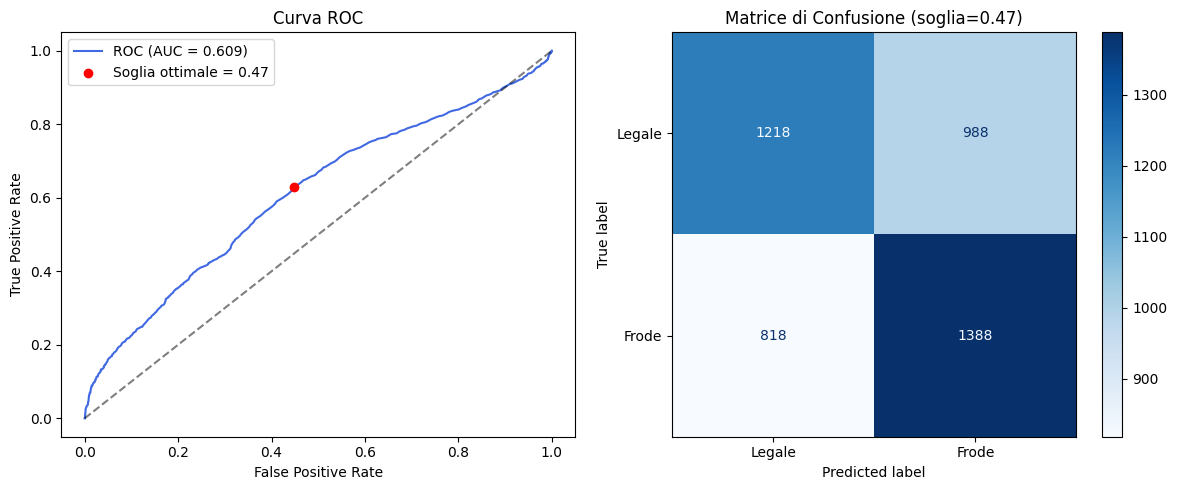

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

# Calcola le probabilità
y_proba = vqc.predict_proba(X_test)
y_scores = y_proba[:, 1]  # probabilità classe Frode

# --- Curva ROC per trovare la soglia ottimale ---
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

# Soglia ottimale = massimizza (tpr - fpr), ovvero il punto più in alto-sinistra della ROC
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f'AUC: {auc:.3f}')
print(f'Soglia ottimale trovata dalla ROC: {optimal_threshold:.3f}')

# Predizione con soglia ottimale
y_pred = (y_scores >= optimal_threshold).astype(int)

print('\n--- Risultati del Modello ---')
print(classification_report(y_test, y_pred, target_names=['Legale', 'Frode']))

# Plot affiancati: ROC + Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Curva ROC
axes[0].plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})', color='royalblue')
axes[0].scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', zorder=5,
                label=f'Soglia ottimale = {optimal_threshold:.2f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC')
axes[0].legend()

# Matrice di Confusione
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legale', 'Frode'])
disp.plot(cmap='Blues', ax=axes[1])
axes[1].set_title(f'Matrice di Confusione (soglia={optimal_threshold:.2f})')

plt.tight_layout()
plt.show()
